In [1]:
1+1

2


\[
\boxed{
\begin{aligned}
\textbf{Population proportion:}\qquad
&\pi\sim\operatorname{Beta}(1,1)
\\[4pt]
\textbf{Latent coding state:}\qquad
&Z_i\mid\pi\sim\operatorname{Bernoulli}(\pi)
\\[4pt]
\textbf{Non-coding model:}\qquad
&A_i\mid Z_i=0\sim f_{0i}
&&\text{(estimated from label shuffles)}
\\[4pt]
\textbf{Coding model:}\qquad
&A_i\mid Z_i=1\sim f_1
&&\text{(signal distribution to be inferred)}
\\[4pt]
\textbf{Observed-data likelihood:}\qquad
&p(A_i\mid\pi)
=(1-\pi)f_{0i}(A_i)+\pi f_1(A_i)
\\[4pt]
\textbf{Posterior outputs:}\qquad
&P(Z_i=1\mid D)
\\
&p(\pi\mid D)
\end{aligned}
}
\]
T

Now Bayes' rule gives
\[
\boxed{
p(\pi,\alpha_1,\beta_1,Z_1,\ldots,Z_N\mid A_1,\ldots,A_N)
\propto
\text{Likelihood}\times\text{Prior}.
}
\]

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Figure 1N decoding results
# ------------------------------------------------------------

decoding = pd.read_csv(
    "../tables1/figure1N_all_subjects_decoding.csv"
)

# ------------------------------------------------------------
# Load Figure 1M permutation results
# ------------------------------------------------------------

perm = pd.read_csv(
    "../tables1/figure1M_all_neuron_permutations.csv"
)

print("Decoding table shape:")
print(decoding.shape)

print("\nPermutation table shape:")
print(perm.shape)

print("\nDecoding columns:")
print(decoding.columns.tolist())

print("\nPermutation columns:")
print(perm.columns.tolist())

display(perm.head())

Decoding table shape:
(554, 13)

Permutation table shape:
(552, 16)

Decoding columns:
['subject', 'neuron', 'region', 'mean_firing_rate_hz', 'n_presentations', 'min_class_count', 'n_splits', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'status', 'error']

Permutation columns:
['subject', 'neuron', 'region', 'FR_accuracy', 'TC_accuracy', 'best_bin_ms', 'best_gamma', 'n_presentations', 'n_splits', 'FR_null_mean', 'FR_p', 'FR_coding', 'TC_null_mean', 'TC_p', 'TC_coding', 'elapsed_seconds']


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFF,9,ent,0.100917,0.165138,180,0.2,109,7,0.106376,0.646766,False,0.105092,0.059701,False,12.667940
1,YFF,10,hpc,0.091743,0.155963,90,0.2,109,7,0.106881,0.731343,False,0.109266,0.094527,False,11.077304
2,YFF,11,hpc,0.110092,0.201835,100,0.5,109,7,0.109404,0.532338,False,0.107248,0.019900,True,10.417088
3,YFF,12,hpc,0.100917,0.174312,300,0.5,109,7,0.110459,0.641791,False,0.108165,0.049751,True,11.636312
4,YFF,13,hpc,0.146789,0.155963,100,0.8,109,7,0.104771,0.159204,False,0.113257,0.139303,False,11.468347


In [4]:
# Keep successful neurons only if status exists
if "status" in decoding.columns:
    decoding_success = decoding[
        decoding["status"] == "success"
    ].copy()
else:
    decoding_success = decoding.copy()


A = decoding_success["TC_accuracy"].dropna()

print("Number of neurons:", len(A))
print()
print("Temporal decoding accuracy:")
print(f"Mean   = {100*A.mean():.2f}%")
print(f"Median = {100*A.median():.2f}%")
print(f"Min    = {100*A.min():.2f}%")
print(f"Max    = {100*A.max():.2f}%")

Number of neurons: 552

Temporal decoding accuracy:
Mean   = 14.58%
Median = 14.39%
Min    = 6.14%
Max    = 28.07%


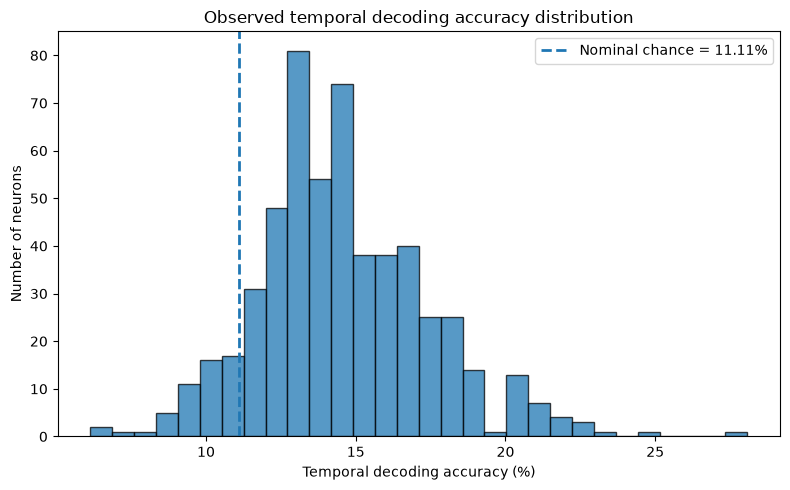

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    100 * A,
    bins=30,
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(
    100/9,
    linestyle="--",
    linewidth=2,
    label="Nominal chance = 11.11%"
)

plt.xlabel("Temporal decoding accuracy (%)")
plt.ylabel("Number of neurons")
plt.title("Observed temporal decoding accuracy distribution")

plt.legend()
plt.tight_layout()
plt.show()

histogram represents our observed mixture:
\[
\boxed{
f(A)
=
(1-\pi)f_0(A)+\pi f_1(A)
}
\]
Conceptually,

In [6]:
import sys
import inspect
from pathlib import Path

# Project root is one level above notebooks1/
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python's import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Notebook location:", Path.cwd())
print("Project root:", PROJECT_ROOT)

# Now import
from src.number_decoding_analysis import permutation_test_decoding

# Print the function
print(inspect.getsource(permutation_test_decoding))

Notebook location: c:\Users\shafi\number-simplex-reproduction\notebooks1
Project root: c:\Users\shafi\number-simplex-reproduction
def permutation_test_decoding(
    X,
    y,
    observed_accuracy,
    gamma,
    n_permutations=200,
    n_splits=10,
    cv_random_state=42,
    permutation_seed=12345,
    alpha=0.05,
):
    """
    Permutation test for single-neuron numeral decoding.

    Parameters
    ----------
    X : ndarray
        Neural features.

    y : ndarray
        Numeral labels.

    observed_accuracy : float
        Cross-validated decoding accuracy obtained using
        the real numeral labels.

    gamma : float
        LDA shrinkage parameter.

    n_permutations : int
        Number of label permutations.

    n_splits : int
        Number of cross-validation folds.

    cv_random_state : int
        Random seed used by cross-validation.

    permutation_seed : int
        Seed controlling label permutations.

    alpha : float
        Significance level used to cl

In [ ]:
import inspect
from src.number_decoding_analysis import permutation_test_decoding

print(inspect.getsource(permutation_test_decoding))

In [7]:
import pandas as pd

path = "../tables1/figure1M_YFU_permutation.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

print("\nFirst row:")
display(df.head(1))

Shape: (62, 16)

Columns:
subject
neuron
region
FR_accuracy
TC_accuracy
best_bin_ms
best_gamma
n_presentations
n_splits
FR_null_mean
FR_p
FR_coding
TC_null_mean
TC_p
TC_coding
elapsed_seconds

First row:


,subject,neuron,region,FR_accuracy,TC_accuracy,best_bin_ms,best_gamma,n_presentations,n_splits,FR_null_mean,FR_p,FR_coding,TC_null_mean,TC_p,TC_coding,elapsed_seconds
0,YFU,1,amy,0.115385,0.121457,225,0.5,494,10,0.10914,0.348259,False,0.109089,0.238806,False,35.466633


In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TABLES = PROJECT_ROOT / "tables1"

# ============================================================
# LOAD EXISTING FIGURE 1M RESULTS
# ============================================================

perm = pd.read_csv(
    TABLES / "figure1M_all_neuron_permutations.csv"
)

print("Total neurons in table:", len(perm))

# ============================================================
# SELECT REPRESENTATIVE NEURONS
#
# Pick neurons near selected quantiles of the observed
# temporal decoding accuracy distribution.
# ============================================================

quantiles = np.linspace(0.05, 0.95, 10)

targets = perm["TC_accuracy"].quantile(quantiles)

selected_rows = []

for q, target in zip(quantiles, targets):

    idx = (
        perm["TC_accuracy"] - target
    ).abs().idxmin()

    row = perm.loc[idx].copy()
    row["selected_quantile"] = q

    selected_rows.append(row)

representative = pd.DataFrame(selected_rows)

# Remove accidental duplicates
representative = (
    representative
    .drop_duplicates(
        subset=["subject", "neuron"]
    )
    .reset_index(drop=True)
)

display(
    representative[
        [
            "selected_quantile",
            "subject",
            "neuron",
            "region",
            "TC_accuracy",
            "best_bin_ms",
            "best_gamma",
            "n_presentations",
            "TC_null_mean",
            "TC_p",
        ]
    ]
)

print(
    "\nSelected neurons:",
    len(representative)
)

Total neurons in table: 552


,selected_quantile,subject,neuron,region,TC_accuracy,best_bin_ms,best_gamma,n_presentations,TC_null_mean,TC_p
0,0.05,YFT,27,hpc,0.104822,60,0.2,477,0.110157,0.726368
1,0.15,YFT,73,ent,0.119497,180,0.2,477,0.111111,0.328358
2,0.25,YFR,5,hpc,0.127820,100,0.8,266,0.110695,0.258706
3,0.35,YFS,35,amy,0.132576,100,0.8,264,0.112481,0.203980
4,0.45,YFJ,17,hpc,0.140351,100,0.2,114,0.103772,0.179104
5,0.55,YFR,2,hpc,0.146617,60,0.5,266,0.111729,0.104478
6,0.65,YFP,37,hpc,0.151899,75,0.2,158,0.107753,0.079602
7,0.75,YFI,3,hpc,0.163462,90,0.2,104,0.105673,0.049751
8,0.85,YFJ,15,hpc,0.175439,100,0.2,114,0.139123,0.129353
9,0.95,YFJ,43,hpc,0.201754,75,0.2,114,0.115789,0.014925



Selected neurons: 10


In [12]:
from src.firing_rate_tuning import analyze_neuron

from src.number_decoding_analysis import (
    make_temporal_features,
    permutation_test_decoding,
)

# ============================================================
# STORAGE
# ============================================================

all_null_rows = []

# ============================================================
# RUN REPRESENTATIVE NEURONS
# ============================================================

for _, row in representative.iterrows():

    subject = row["subject"]
    neuron = int(row["neuron"])

    best_bin = int(row["best_bin_ms"])
    best_gamma = float(row["best_gamma"])

    observed_accuracy = float(row["TC_accuracy"])
    n_splits = int(row["n_splits"])

    print("\n" + "=" * 65)
    print(
        f"{subject} neuron {neuron} | "
        f"observed = {100*observed_accuracy:.2f}% | "
        f"bin = {best_bin} ms | "
        f"gamma = {best_gamma}"
    )
    print("=" * 65)

    # --------------------------------------------------------
    # Reconstruct this neuron's presentations and spike times
    # --------------------------------------------------------

    result = analyze_neuron(
        subject=subject,
        neuron=neuron,
        root=PROJECT_ROOT,
        plot=False,
        verbose=False,
    )

    presentations = result["presentations"]
    spike_times = result["spike_times"]

    # --------------------------------------------------------
    # Temporal feature matrix using the already-selected
    # best temporal bin
    # --------------------------------------------------------

    X, y, bin_edges = make_temporal_features(
        presentations,
        spike_times,
        bin_size=best_bin,
        window_start=50,
        window_end=950,
    )

    # --------------------------------------------------------
    # Generate empirical null distribution
    # --------------------------------------------------------

    null_result = permutation_test_decoding(
        X=X,
        y=y,
        observed_accuracy=observed_accuracy,
        gamma=best_gamma,
        n_permutations=200,
        n_splits=n_splits,
        cv_random_state=42,
        permutation_seed=12345,
    )

    null_accuracies = null_result["null_accuracies"]

    print(
        f"Null mean = "
        f"{100*np.mean(null_accuracies):.2f}%"
    )

    print(
        f"Null SD   = "
        f"{100*np.std(null_accuracies, ddof=1):.2f}%"
    )

    # --------------------------------------------------------
    # SAVE ALL 200 VALUES
    # --------------------------------------------------------

    for permutation_number, null_accuracy in enumerate(
        null_accuracies,
        start=1,
    ):

        all_null_rows.append(
            {
                "subject": subject,
                "neuron": neuron,
                "region": row["region"],
                "n_presentations": int(row["n_presentations"]),
                "best_bin_ms": best_bin,
                "best_gamma": best_gamma,
                "observed_TC_accuracy": observed_accuracy,
                "permutation": permutation_number,
                "null_accuracy": null_accuracy,
            }
        )


# ============================================================
# COMBINE EVERYTHING
# ============================================================

null_df = pd.DataFrame(all_null_rows)

output_file = (
    TABLES /
    "bayesian_representative_null_distributions.csv"
)

null_df.to_csv(
    output_file,
    index=False,
)

print("\nSaved:")
print(output_file)

print("\nShape:", null_df.shape)

display(null_df.head())


YFT neuron 27 | observed = 10.48% | bin = 60 ms | gamma = 0.2
Null mean = 11.06%
Null SD   = 1.05%

YFT neuron 73 | observed = 11.95% | bin = 180 ms | gamma = 0.2
Null mean = 11.13%
Null SD   = 1.44%

YFR neuron 5 | observed = 12.78% | bin = 100 ms | gamma = 0.8
Null mean = 11.02%
Null SD   = 2.18%

YFS neuron 35 | observed = 13.26% | bin = 100 ms | gamma = 0.8
Null mean = 11.02%
Null SD   = 2.14%

YFJ neuron 17 | observed = 14.04% | bin = 100 ms | gamma = 0.2
Null mean = 10.57%
Null SD   = 3.40%

YFR neuron 2 | observed = 14.66% | bin = 60 ms | gamma = 0.5
Null mean = 11.02%
Null SD   = 2.73%

YFP neuron 37 | observed = 15.19% | bin = 75 ms | gamma = 0.2
Null mean = 11.12%
Null SD   = 2.86%

YFI neuron 3 | observed = 16.35% | bin = 90 ms | gamma = 0.2
Null mean = 11.09%
Null SD   = 3.50%

YFJ neuron 15 | observed = 17.54% | bin = 100 ms | gamma = 0.2
Null mean = 13.61%
Null SD   = 3.59%

YFJ neuron 43 | observed = 20.18% | bin = 75 ms | gamma = 0.2
Null mean = 11.29%
Null SD   = 3.32

,subject,neuron,region,n_presentations,best_bin_ms,best_gamma,observed_TC_accuracy,permutation,null_accuracy
0,YFT,27,hpc,477,60,0.2,0.104822,1,0.115304
1,YFT,27,hpc,477,60,0.2,0.104822,2,0.109015
2,YFT,27,hpc,477,60,0.2,0.104822,3,0.104822
3,YFT,27,hpc,477,60,0.2,0.104822,4,0.090147
4,YFT,27,hpc,477,60,0.2,0.104822,5,0.113208


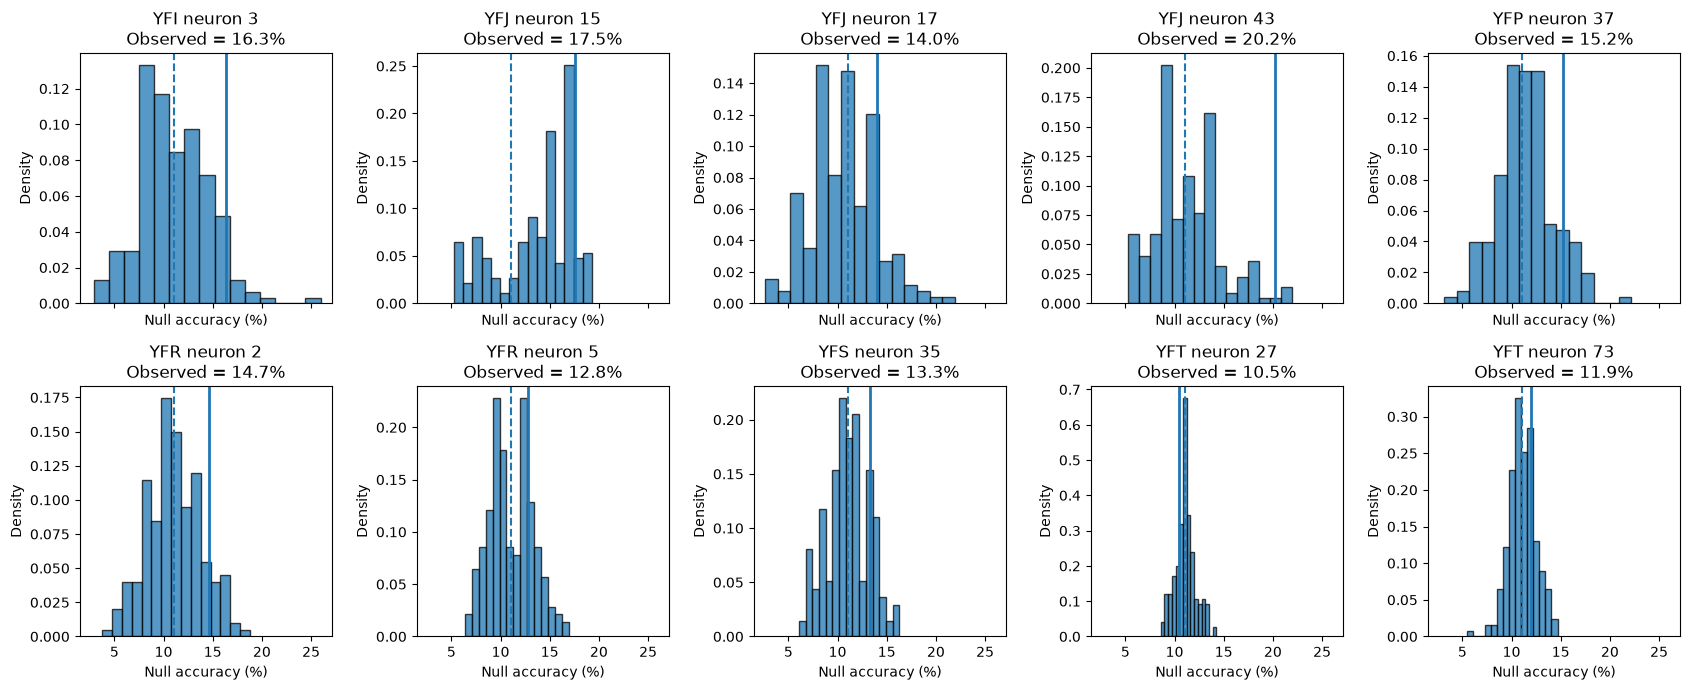

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 5,
    figsize=(17, 7),
    sharex=True
)

axes = axes.flatten()

for ax, ((subject, neuron), group) in zip(
    axes,
    null_df.groupby(["subject", "neuron"])
):

    observed = group["observed_TC_accuracy"].iloc[0]

    ax.hist(
        100 * group["null_accuracy"],
        bins=15,
        alpha=0.75,
        edgecolor="black",
        density=True
    )

    # Observed decoding accuracy
    ax.axvline(
        100 * observed,
        linestyle="-",
        linewidth=2,
        label="Observed"
    )

    # Nominal 9-class chance
    ax.axvline(
        100 / 9,
        linestyle="--",
        linewidth=1.5,
        label="11.11%"
    )

    ax.set_title(
        f"{subject} neuron {neuron}\n"
        f"Observed = {100*observed:.1f}%"
    )

    ax.set_xlabel("Null accuracy (%)")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

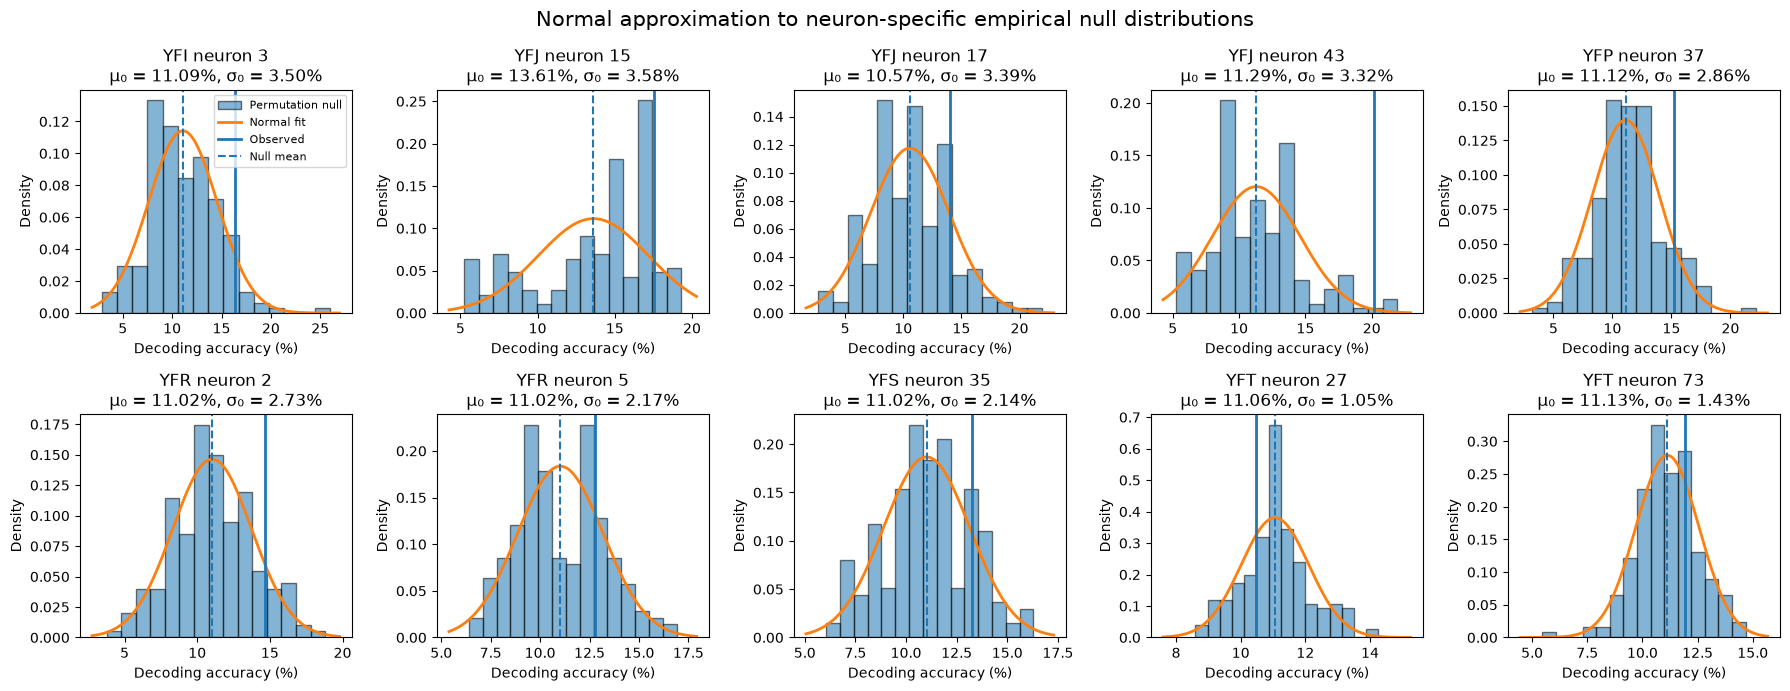

,subject,neuron,observed_accuracy_pct,null_mu_pct,null_sigma_pct
0,YFI,3,16.35,11.09,3.50
1,YFJ,15,17.54,13.61,3.58
2,YFJ,17,14.04,10.57,3.39
3,YFJ,43,20.18,11.29,3.32
4,YFP,37,15.19,11.12,2.86
5,YFR,2,14.66,11.02,2.73
6,YFR,5,12.78,11.02,2.17
7,YFS,35,13.26,11.02,2.14
8,YFT,27,10.48,11.06,1.05
9,YFT,73,11.95,11.13,1.43


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# FIT NORMAL DISTRIBUTION TO EACH EMPIRICAL NULL
# ============================================================

groups = list(
    null_df.groupby(["subject", "neuron"])
)

fig, axes = plt.subplots(
    2, 5,
    figsize=(18, 7)
)

axes = axes.flatten()

normal_fit_results = []

for ax, ((subject, neuron), group) in zip(axes, groups):

    # --------------------------------------------------------
    # Null permutation accuracies
    # --------------------------------------------------------

    null_values = group["null_accuracy"].to_numpy()

    observed = group["observed_TC_accuracy"].iloc[0]

    # --------------------------------------------------------
    # Fit Normal distribution
    # MLE estimates
    # --------------------------------------------------------

    mu, sigma = norm.fit(null_values)

    # Save results
    normal_fit_results.append(
        {
            "subject": subject,
            "neuron": neuron,
            "observed_accuracy": observed,
            "null_mu": mu,
            "null_sigma": sigma,
        }
    )

    # --------------------------------------------------------
    # Histogram of empirical permutation distribution
    # --------------------------------------------------------

    ax.hist(
        100 * null_values,
        bins=15,
        density=True,
        alpha=0.55,
        edgecolor="black",
        label="Permutation null"
    )

    # --------------------------------------------------------
    # Normal density
    #
    # Work in percentage units so that histogram and
    # Normal density are on the same scale.
    # --------------------------------------------------------

    mu_pct = 100 * mu
    sigma_pct = 100 * sigma

    x = np.linspace(
        100 * null_values.min() - 1,
        100 * null_values.max() + 1,
        400
    )

    normal_density = norm.pdf(
        x,
        loc=mu_pct,
        scale=sigma_pct
    )

    ax.plot(
        x,
        normal_density,
        linewidth=2,
        label="Normal fit"
    )

    # --------------------------------------------------------
    # Observed accuracy
    # --------------------------------------------------------

    ax.axvline(
        100 * observed,
        linestyle="-",
        linewidth=2,
        label="Observed"
    )

    # Null mean
    ax.axvline(
        mu_pct,
        linestyle="--",
        linewidth=1.5,
        label="Null mean"
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_title(
        f"{subject} neuron {neuron}\n"
        f"μ₀ = {mu_pct:.2f}%, "
        f"σ₀ = {sigma_pct:.2f}%"
    )

    ax.set_xlabel("Decoding accuracy (%)")
    ax.set_ylabel("Density")


# Only show legend once
axes[0].legend(
    fontsize=8
)

plt.suptitle(
    "Normal approximation to neuron-specific empirical null distributions",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ============================================================
# FIT SUMMARY
# ============================================================

normal_fit_df = pd.DataFrame(normal_fit_results)

normal_fit_df["observed_accuracy_pct"] = (
    100 * normal_fit_df["observed_accuracy"]
)

normal_fit_df["null_mu_pct"] = (
    100 * normal_fit_df["null_mu"]
)

normal_fit_df["null_sigma_pct"] = (
    100 * normal_fit_df["null_sigma"]
)

display(
    normal_fit_df[
        [
            "subject",
            "neuron",
            "observed_accuracy_pct",
            "null_mu_pct",
            "null_sigma_pct",
        ]
    ].round(2)
)

In [15]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd
from scipy.stats import norm

# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TABLES = PROJECT_ROOT / "tables1"

# ============================================================
# EXISTING FUNCTIONS
# ============================================================

from src.firing_rate_tuning import analyze_neuron

from src.number_decoding_analysis import (
    make_temporal_features,
    permutation_test_decoding,
)

# ============================================================
# LOAD ALL FIGURE 1M NEURONS
# ============================================================

perm = pd.read_csv(
    TABLES / "figure1M_all_neuron_permutations.csv"
)

# Keep valid rows
perm = perm[
    perm["TC_accuracy"].notna()
    & perm["best_bin_ms"].notna()
    & perm["best_gamma"].notna()
].copy()

perm = perm.reset_index(drop=True)

print("Neurons to process:", len(perm))


# ============================================================
# OUTPUT FILES
# ============================================================

FULL_NULL_FILE = (
    TABLES /
    "bayesian_all_neuron_null_distributions.csv"
)

NORMAL_FIT_FILE = (
    TABLES /
    "bayesian_all_neuron_normal_null_fits.csv"
)


# ============================================================
# STORAGE
# ============================================================

all_null_rows = []
normal_fit_rows = []

start_time = time.time()


# ============================================================
# RUN ALL NEURONS
# ============================================================

for j, row in perm.iterrows():

    subject = row["subject"]
    neuron = int(row["neuron"])
    region = row["region"]

    observed_accuracy = float(
        row["TC_accuracy"]
    )

    best_bin = int(
        row["best_bin_ms"]
    )

    best_gamma = float(
        row["best_gamma"]
    )

    n_splits = int(
        row["n_splits"]
    )

    # --------------------------------------------------------
    # Load neuron
    # --------------------------------------------------------

    result = analyze_neuron(
        subject=subject,
        neuron=neuron,
        root=PROJECT_ROOT,
        plot=False,
        verbose=False,
    )

    presentations = result["presentations"]
    spike_times = result["spike_times"]

    # --------------------------------------------------------
    # Reconstruct temporal features
    # --------------------------------------------------------

    X, y, bin_edges = make_temporal_features(
        presentations,
        spike_times,
        bin_size=best_bin,
        window_start=50,
        window_end=950,
    )

    # --------------------------------------------------------
    # Generate 200 null accuracies
    # --------------------------------------------------------

    null_result = permutation_test_decoding(
        X=X,
        y=y,
        observed_accuracy=observed_accuracy,
        gamma=best_gamma,
        n_permutations=200,
        n_splits=n_splits,
        cv_random_state=42,
        permutation_seed=12345,
    )

    null_accuracies = np.asarray(
        null_result["null_accuracies"]
    )

    # ========================================================
    # FIT NORMAL NULL
    # ========================================================

    mu0, sigma0 = norm.fit(
        null_accuracies
    )

    # Observed accuracy relative to fitted null
    if sigma0 > 0:
        z_null = (
            observed_accuracy - mu0
        ) / sigma0
    else:
        z_null = np.nan

    # --------------------------------------------------------
    # Store fitted Normal parameters
    # --------------------------------------------------------

    normal_fit_rows.append(
        {
            "subject": subject,
            "neuron": neuron,
            "region": region,

            "n_presentations":
                int(row["n_presentations"]),

            "n_splits":
                n_splits,

            "best_bin_ms":
                best_bin,

            "best_gamma":
                best_gamma,

            "observed_TC_accuracy":
                observed_accuracy,

            "null_mu":
                mu0,

            "null_sigma":
                sigma0,

            "observed_null_z":
                z_null,
        }
    )

    # --------------------------------------------------------
    # Store ALL 200 permutation values
    # --------------------------------------------------------

    for permutation_number, null_accuracy in enumerate(
        null_accuracies,
        start=1
    ):

        all_null_rows.append(
            {
                "subject": subject,
                "neuron": neuron,
                "region": region,

                "permutation":
                    permutation_number,

                "null_accuracy":
                    null_accuracy,
            }
        )

    # ========================================================
    # PROGRESS
    # ========================================================

    completed = j + 1

    if (
        completed == 1
        or completed % 10 == 0
        or completed == len(perm)
    ):

        elapsed = time.time() - start_time

        rate = elapsed / completed

        remaining = (
            len(perm) - completed
        ) * rate

        print(
            f"{completed:3d}/{len(perm)} | "
            f"{subject} neuron {neuron} | "
            f"obs={100*observed_accuracy:.2f}% | "
            f"μ0={100*mu0:.2f}% | "
            f"σ0={100*sigma0:.2f}% | "
            f"z={z_null:.2f} | "
            f"ETA={remaining/60:.1f} min"
        )

    # ========================================================
    # CHECKPOINT EVERY 25 NEURONS
    # ========================================================

    if completed % 25 == 0:

        pd.DataFrame(
            normal_fit_rows
        ).to_csv(
            NORMAL_FIT_FILE,
            index=False
        )

        pd.DataFrame(
            all_null_rows
        ).to_csv(
            FULL_NULL_FILE,
            index=False
        )


# ============================================================
# FINAL SAVE
# ============================================================

normal_fits = pd.DataFrame(
    normal_fit_rows
)

all_nulls = pd.DataFrame(
    all_null_rows
)

normal_fits.to_csv(
    NORMAL_FIT_FILE,
    index=False
)

all_nulls.to_csv(
    FULL_NULL_FILE,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

elapsed = time.time() - start_time

print("\n" + "=" * 60)
print("COMPLETE")
print("=" * 60)

print(
    f"Neurons processed: {len(normal_fits)}"
)

print(
    f"Null accuracies saved: {len(all_nulls):,}"
)

print(
    f"Total time: {elapsed/60:.2f} minutes"
)

print("\nNormal null fits:")
print(NORMAL_FIT_FILE)

print("\nFull empirical null distributions:")
print(FULL_NULL_FILE)


# ============================================================
# DISPLAY SUMMARY
# ============================================================

summary = normal_fits.copy()

summary["observed_pct"] = (
    100 * summary["observed_TC_accuracy"]
)

summary["null_mean_pct"] = (
    100 * summary["null_mu"]
)

summary["null_sd_pct"] = (
    100 * summary["null_sigma"]
)

display(
    summary[
        [
            "subject",
            "neuron",
            "region",
            "observed_pct",
            "null_mean_pct",
            "null_sd_pct",
            "observed_null_z",
        ]
    ].head(20).round(3)
)

Neurons to process: 552
  1/552 | YFF neuron 9 | obs=16.51% | μ0=10.88% | σ0=3.31% | z=1.70 | ETA=46.8 min


KeyboardInterrupt: 

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, beta
from scipy.optimize import minimize

df = pd.read_csv(
    "../tables1/figure1M_all_neuron_permutations.csv"
)

df = df[
    df["TC_accuracy"].notna()
].copy()

A = df["TC_accuracy"].to_numpy()

print("Number of neurons:", len(A))
print(f"Mean accuracy: {100*A.mean():.2f}%")
print(f"Min accuracy:  {100*A.min():.2f}%")
print(f"Max accuracy:  {100*A.max():.2f}%")

Number of neurons: 552
Mean accuracy: 14.58%
Min accuracy:  6.14%
Max accuracy:  28.07%


In [17]:
# ============================================================
# NULL MODEL
# ============================================================

MU0 = 1 / 9       # 0.1111
SIGMA0 = 0.02     # assumed 2% SD

f0 = norm.pdf(
    A,
    loc=MU0,
    scale=SIGMA0
)

print("Null mean:", MU0)
print("Null SD:", SIGMA0)

Null mean: 0.1111111111111111
Null SD: 0.02


In [18]:
# ============================================================
# NEGATIVE LOG-LIKELIHOOD
# ============================================================

def negative_log_likelihood(params):

    # Transform unconstrained parameters
    # into valid parameter ranges

    logit_pi, log_alpha, log_beta = params

    pi = 1 / (1 + np.exp(-logit_pi))

    alpha1 = np.exp(log_alpha)
    beta1 = np.exp(log_beta)

    # Null density
    null_density = norm.pdf(
        A,
        loc=MU0,
        scale=SIGMA0
    )

    # Signal density
    signal_density = beta.pdf(
        A,
        a=alpha1,
        b=beta1
    )

    # Mixture
    mixture_density = (
        (1 - pi) * null_density
        +
        pi * signal_density
    )

    # Avoid log(0)
    mixture_density = np.maximum(
        mixture_density,
        1e-300
    )

    return -np.sum(
        np.log(mixture_density)
    )


# ============================================================
# INITIAL VALUES
# ============================================================

initial_pi = 0.25

initial_alpha = 5
initial_beta = 25

initial_params = [
    np.log(initial_pi / (1 - initial_pi)),
    np.log(initial_alpha),
    np.log(initial_beta)
]


# ============================================================
# OPTIMIZE
# ============================================================

fit = minimize(
    negative_log_likelihood,
    initial_params,
    method="L-BFGS-B"
)

print("Optimization success:", fit.success)
print(fit.message)


# ============================================================
# EXTRACT PARAMETERS
# ============================================================

logit_pi, log_alpha, log_beta = fit.x

pi_hat = 1 / (
    1 + np.exp(-logit_pi)
)

alpha_hat = np.exp(log_alpha)
beta_hat = np.exp(log_beta)

print("\nEstimated parameters")
print("=" * 40)

print(
    f"Estimated coding proportion π = "
    f"{100*pi_hat:.2f}%"
)

print(
    f"Signal Beta alpha = "
    f"{alpha_hat:.3f}"
)

print(
    f"Signal Beta beta  = "
    f"{beta_hat:.3f}"
)

signal_mean = (
    alpha_hat /
    (alpha_hat + beta_hat)
)

print(
    f"Signal mean accuracy = "
    f"{100*signal_mean:.2f}%"
)

Optimization success: True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Estimated parameters
Estimated coding proportion π = 98.08%
Signal Beta alpha = 22.673
Signal Beta beta  = 132.052
Signal mean accuracy = 14.65%


In [19]:
# ============================================================
# DENSITIES AT EACH OBSERVED ACCURACY
# ============================================================

null_density = norm.pdf(
    A,
    loc=MU0,
    scale=SIGMA0
)

signal_density = beta.pdf(
    A,
    a=alpha_hat,
    b=beta_hat
)


# ============================================================
# POSTERIOR PROBABILITY OF CODING
# ============================================================

numerator = (
    pi_hat * signal_density
)

denominator = (
    (1 - pi_hat) * null_density
    +
    pi_hat * signal_density
)

P_coding = (
    numerator / denominator
)


# ============================================================
# SAVE INTO TABLE
# ============================================================

df["bayes_P_coding"] = P_coding

display(
    df[
        [
            "subject",
            "neuron",
            "region",
            "TC_accuracy",
            "bayes_P_coding"
        ]
    ]
    .sort_values(
        "bayes_P_coding",
        ascending=False
    )
    .head(20)
)

,subject,neuron,region,TC_accuracy,bayes_P_coding
113,YFK,27,hpc,0.280702,1.000000
106,YFJ,58,hpc,0.245614,1.000000
242,YFM,65,hpc,0.236842,1.000000
33,YFF,51,hpc,0.229358,1.000000
229,YFM,41,ent,0.228070,1.000000
129,YFK,43,para-hpc,0.228070,1.000000
222,YFM,34,ent,0.219298,1.000000
170,YFL,36,hpc,0.219298,1.000000
188,YFL,72,hpc,0.219298,1.000000
258,YFM,81,hpc,0.219298,1.000000


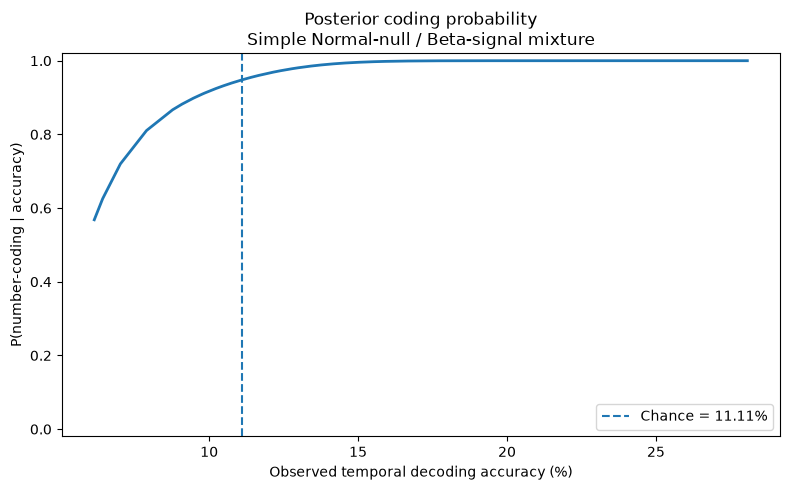

In [20]:
order = np.argsort(A)

plt.figure(figsize=(8, 5))

plt.plot(
    100 * A[order],
    P_coding[order],
    linewidth=2
)

plt.axvline(
    100 / 9,
    linestyle="--",
    label="Chance = 11.11%"
)

plt.xlabel(
    "Observed temporal decoding accuracy (%)"
)

plt.ylabel(
    "P(number-coding | accuracy)"
)

plt.title(
    "Posterior coding probability\n"
    "Simple Normal-null / Beta-signal mixture"
)

plt.ylim(-0.02, 1.02)

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
import pymc as pm
import arviz as az

print("PyMC:", pm.__version__)
print("ArviZ:", az.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
ArviZ: 1.3.0


In [22]:
%pip install pymc

   ---------------------------------------- 0.0/608.3 kB ? eta -:--:--
   ---------------------------------------- 608.3/608.3 kB 5.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 9.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 26.2 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ------- -------------------------------- 7.6/41.9 MB 42.6 MB/s eta 0:00:01
   ------- -------------------------------- 7.6/41.9 MB 42.6 MB/s eta 0:00:01
   --------- ------------------------------ 9.4/41.9 MB 15.0 MB/s eta 0:00:03
   ----------- ---------------------------- 12.1/41.9 MB 14.4 MB/s eta 0:00:03
   ------------- ------------------------

In [23]:
%pip install arviz

Note: you may need to restart the kernel to use updated packages.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../tables1/figure1M_all_neuron_permutations.csv"
)

df = df[
    df["TC_accuracy"].notna()
].copy()

A = df["TC_accuracy"].to_numpy(dtype=float)

N = len(A)

chance = 1 / 9
sigma0 = 0.02

print("N =", N)
print(f"Chance = {100*chance:.2f}%")
print(f"Assumed null SD = {100*sigma0:.2f}%")
print(f"Observed mean = {100*A.mean():.2f}%")
print(f"Observed range = {100*A.min():.2f}% to {100*A.max():.2f}%")

N = 552
Chance = 11.11%
Assumed null SD = 2.00%
Observed mean = 14.58%
Observed range = 6.14% to 28.07%


In [26]:
with model:

    trace = pm.sample(
        draws=3000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )

NameError: name 'model' is not defined

In [27]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az

# ============================================================
# SIMPLE BAYESIAN MIXTURE MODEL
# ============================================================

chance = 1 / 9
sigma0 = 0.02

A_tensor = pt.as_tensor_variable(A)

with pm.Model() as model:

    # --------------------------------------------------------
    # PRIOR: proportion of number-coding neurons
    # --------------------------------------------------------

    pi = pm.Beta(
        "pi",
        alpha=1,
        beta=1
    )

    # --------------------------------------------------------
    # PRIORS: shape of signal distribution
    # --------------------------------------------------------

    alpha_signal = pm.LogNormal(
        "alpha_signal",
        mu=np.log(2),
        sigma=1.0
    )

    beta_signal = pm.LogNormal(
        "beta_signal",
        mu=np.log(20),
        sigma=1.0
    )

    # --------------------------------------------------------
    # NULL DISTRIBUTION
    #
    # Accuracy | non-coding ~ Normal(11.11%, 2%^2)
    # --------------------------------------------------------

    null_dist = pm.Normal.dist(
        mu=chance,
        sigma=sigma0
    )

    log_f0 = pm.logp(
        null_dist,
        A_tensor
    )

    # --------------------------------------------------------
    # SIGNAL DISTRIBUTION
    #
    # Shifted Beta distribution on [chance, 1]
    # --------------------------------------------------------

    r = (
        (A_tensor - chance)
        /
        (1 - chance)
    )

    r_safe = pt.clip(
        r,
        1e-9,
        1 - 1e-9
    )

    signal_dist = pm.Beta.dist(
        alpha=alpha_signal,
        beta=beta_signal
    )

    log_f1 = pm.logp(
        signal_dist,
        r_safe
    )

    # Jacobian from transforming r -> accuracy
    log_f1 = (
        log_f1
        - np.log(1 - chance)
    )

    # Signal has zero density below/equal to chance
    log_f1 = pt.switch(
        pt.gt(A_tensor, chance),
        log_f1,
        -np.inf
    )

    # --------------------------------------------------------
    # MIXTURE
    #
    # (1-pi) f0(A) + pi f1(A)
    # --------------------------------------------------------

    log_null = (
        pt.log(1 - pi)
        + log_f0
    )

    log_signal = (
        pt.log(pi)
        + log_f1
    )

    log_mixture = pt.logaddexp(
        log_null,
        log_signal
    )

    pm.Potential(
        "likelihood",
        pt.sum(log_mixture)
    )

    # --------------------------------------------------------
    # SAMPLE POSTERIOR
    # --------------------------------------------------------

    trace = pm.sample(
        draws=3000,
        tune=2000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=42,
        return_inferencedata=True
    )


# ============================================================
# POSTERIOR SUMMARY
# ============================================================

summary = az.summary(
    trace,
    var_names=[
        "pi",
        "alpha_signal",
        "beta_signal"
    ],
    hdi_prob=0.95
)

display(summary)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi, alpha_signal, beta_signal]


Output()

Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 12 seconds.


TypeError: summary() got an unexpected keyword argument 'hdi_prob'. Did you mean 'ci_prob'?